# Nested sampling

*Davide Gerosa (Milano-Bicocca)*


This course is based on previous work by many people. 

---

MCMCs are great and often my go-to option for parameter estimation (easy to setup, easy to understand what's going on, easy to conquer the world).

The crucial limitation is that they don't provide the evidence, which is the key ingredient one needs for model selection.

Let's look at another algorithm that instead does provide the evidence (but it's more complicated...)

# Integrating the evidence with nested sampling

Nested sampling is a very different MCMC method from Metropolis-Hastings or even Gibbs approaches. It's very recent and nonetheless very popular. The [first paper is from 2004 by Skilling](https://ui.adsabs.harvard.edu/abs/2004AIPC..735..395S).


- One starts with many points spread throughout the prior volume.
- The points are ranked in terms of their likelihood.
- The lowest ranked point is removed, and a higher likelihood point is randomly added.
- This is repeated, until the cluster of points climbs up the likelihood surface, accumulating Bayesian evidence information along the way. 

The prior volume is defined as $dX = p(\theta)d^n\theta$ such that $X(\lambda) = \int_{p(d|\theta)>\lambda}p(\theta)d^n\theta$, where the integral is over the model parameter region that exceeds the iso-likelihood contour $p(d|\theta)=L(\theta)=\lambda$.

This transforms the evidence integral into 

$$\mathcal{Z} = \int p(d|\theta)p(\theta)d^n\theta = \int_0^1 L(X)dX.$$


Here is how the algorithm works:


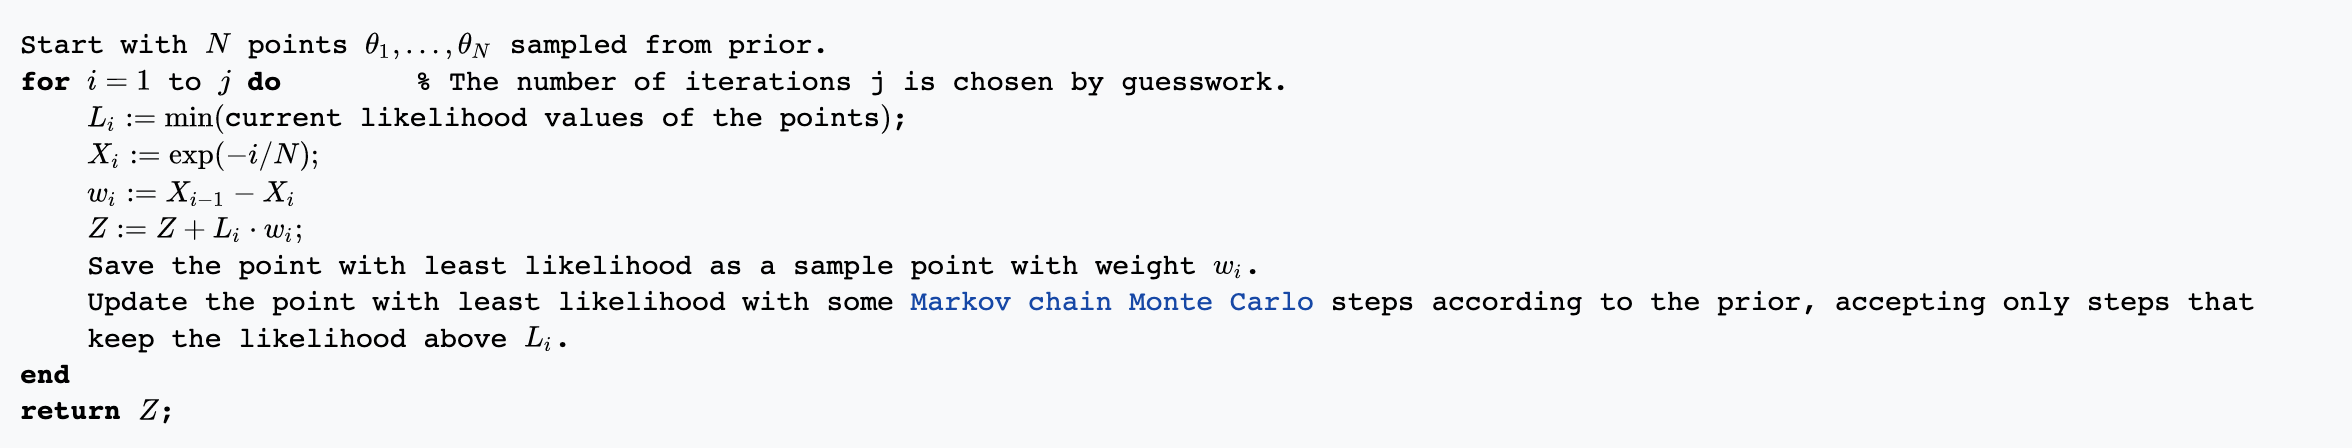

([credits](https://en.wikipedia.org/wiki/Nested_sampling_algorithm))


The form of the $X_{i}$ is not unique, but it needs to be an estimator of the amount of prior mass in the parameter space of all points with likelihood greater than $L_i$. See [Skilling 2006](https://projecteuclid.org/journals/bayesian-analysis/volume-1/issue-4/Nested-sampling-for-general-Bayesian-computation/10.1214/06-BA127.full) for more.

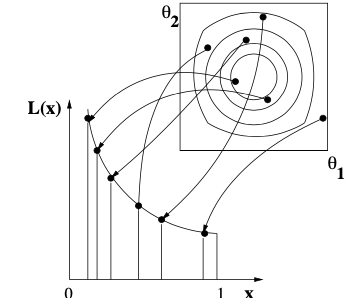


This paper is a nice example from the field of cosmology: https://arxiv.org/abs/astro-ph/0508461




There are several popular packages that perform nested sampling, and not only do they all compute the Bayesian evidence but they also produce posterior samples as a by-product. 


By far the most historically well known is [`MultiNest`](https://github.com/rjw57/MultiNest) and its Python wrapper [`PyMultiNest`](https://johannesbuchner.github.io/PyMultiNest/). It used to be (and may still be) a bit of a pain to install though (there is C and Fortran involved). Refs [here](https://ui.adsabs.harvard.edu/abs/2004AIPC..735..395S/abstract), and [here](https://academic.oup.com/mnras/article/398/4/1601/981502?login=true).


So while this is the big one, there seem to be other more pythonic implementations now on the market. Let's look at two of them in particular, which are used in my research field.

---

### Dynesty <a class="anchor" id="twoa"></a>

It's as recent as 2019. https://arxiv.org/abs/1904.02180

![](https://github.com/joshspeagle/dynesty/blob/master/docs/images/title.gif?raw=true)

This example comes from the [dynesty](https://arxiv.org/abs/1904.02180) ["crash course"](https://dynesty.readthedocs.io/en/latest/crashcourse.html). We define our likelihood to be a $3$D correlated multivariate Gaussian distribution, and our prior to be uniform in each dimension from $-10$ to $10$.

In [16]:
import dynesty
import numpy as np

# Define the dimensionality of our problem.
ndim = 3

# Define our 3-D correlated multivariate normal likelihood.
C = np.identity(ndim)  # set covariance to identity matrix
C[C==0] = 0.95  # set off-diagonal terms
Cinv = np.linalg.inv(C)  # define the inverse (i.e. the precision matrix)
lnorm = -0.5 * (np.log(2 * np.pi) * ndim +
                np.log(np.linalg.det(C)))  # ln(normalization)


In [17]:
C

array([[1.  , 0.95, 0.95],
       [0.95, 1.  , 0.95],
       [0.95, 0.95, 1.  ]])

In [18]:
def loglike(x):
    """The log-likelihood function."""

    return -0.5 * np.dot(x, np.dot(Cinv, x)) + lnorm # Notice I need the correct normalization now! 
 
# Define our uniform prior.
def ptform(u):
    """Transforms samples `u` drawn from the unit cube to samples to those
    from our uniform prior within [-10., 10.) for each variable."""

    return 10. * (2. * u - 1.)

Run the sampler. 

In [19]:
# "Static" nested sampling.
sampler = dynesty.NestedSampler(loglike, ptform, ndim)
sampler.run_nested( dlogz=1e-6)
sresults = sampler.results

11310it [00:03, 3221.60it/s, +500 | bound: 32 | nc: 1 | ncall: 34269 | eff(%): 34.973 | loglstar:   -inf < -0.293 <    inf | logz: -9.074 +/-  0.121 | dlogz:  0.000 >  0.000]


You've just estimated the Bayesian evidence and posterior. Plot the results. These figures will have an $x$-axis that is $-\ln X$ which is a bit confusing to think about to begin with, but remember that we are moving up the likelihood contours when going from left to right on the graphs.

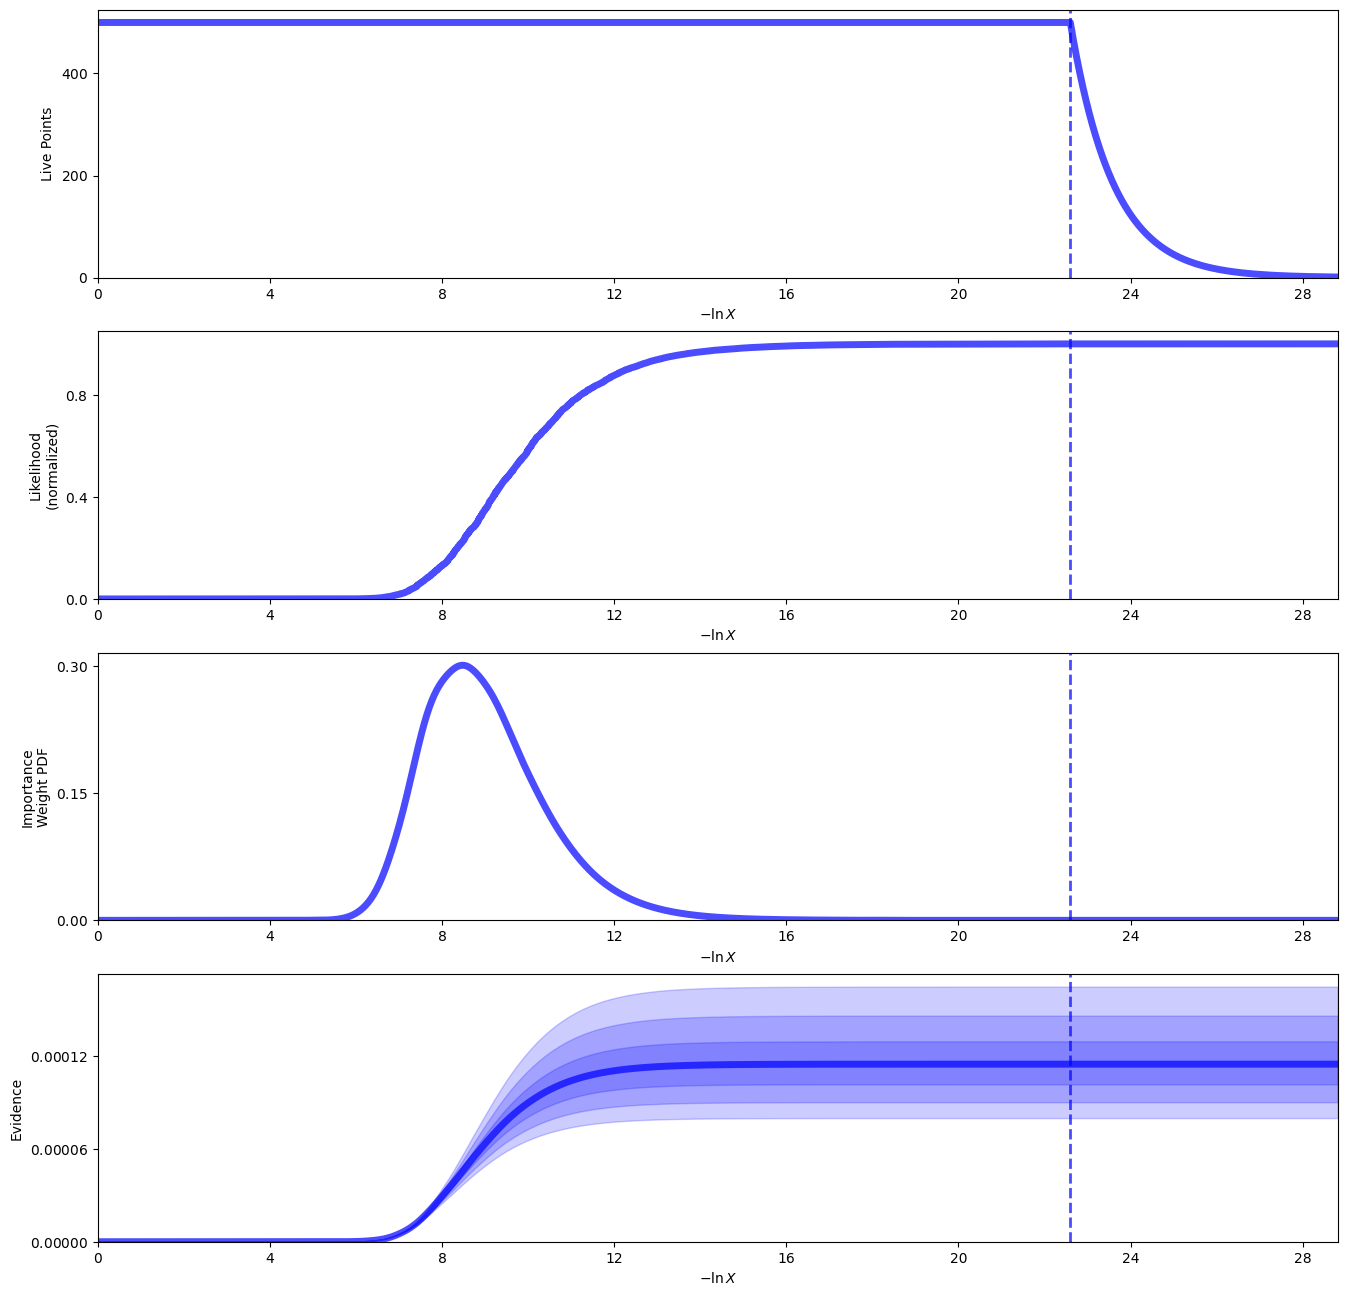

In [20]:
from dynesty import plotting as dyplot

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults)

How to interpret this... (Figure from https://arxiv.org/abs/1904.02180)

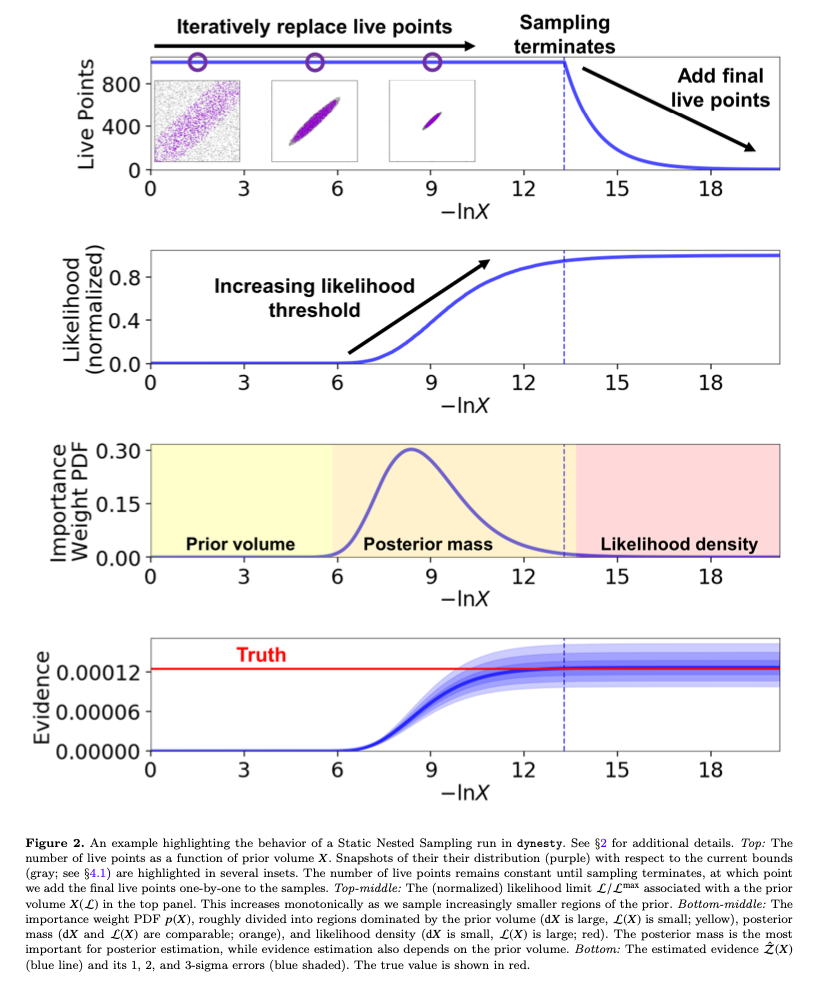

Plot parameter traces and 1-D marginalized posteriors. On the left panels, you'll see that the live points started out scattereed across the prior volume, then move inwards as the sampler climbs the likelihood.

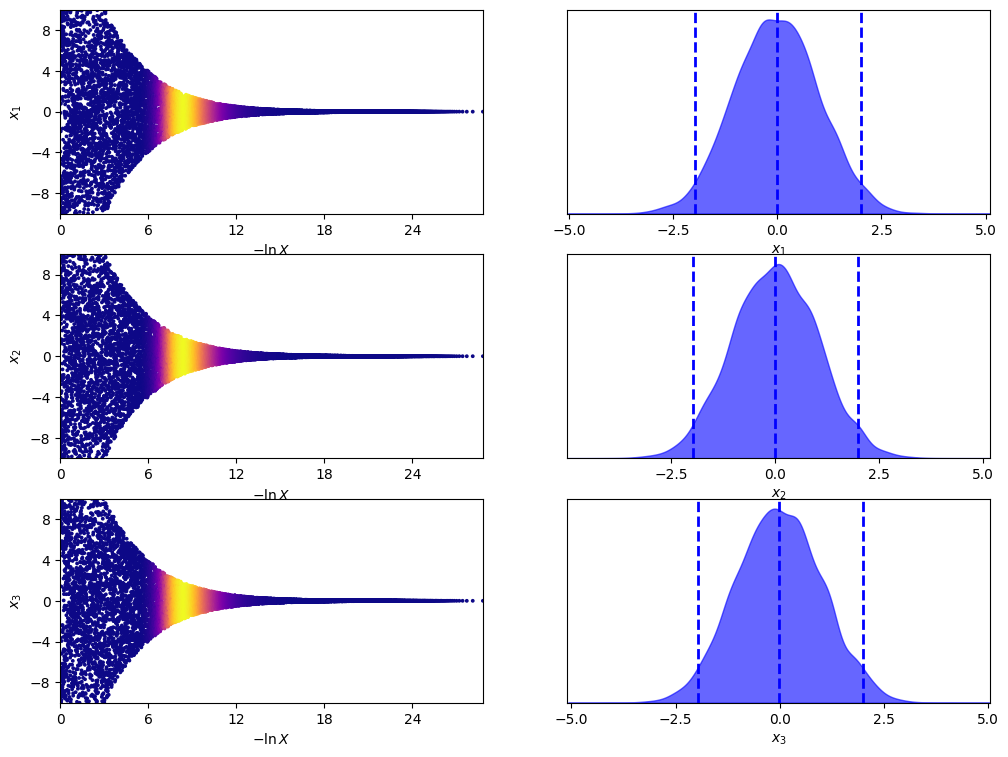

In [21]:
tfig, taxes = dyplot.traceplot(sresults)

Plot the 2-D marginalized posteriors using `dynesty` routines. (But you could also use `corner` if you wish).

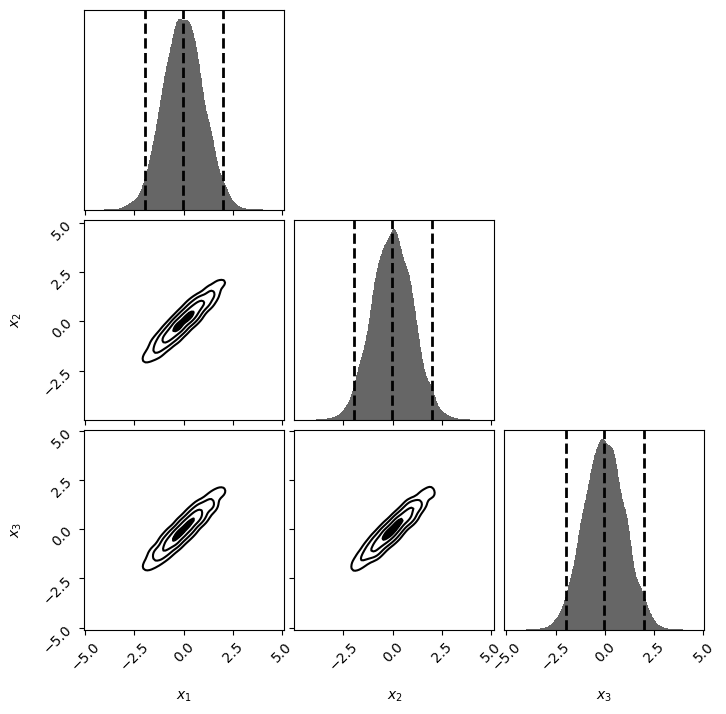

In [22]:
cfig, caxes = dyplot.cornerplot(sresults)

`dynesty` also lets you access many other utilities and analysis outputs. See below. 

In [23]:
from dynesty import utils as dyfunc


# Extract sampling results.
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights


evidence = sresults.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))


# Generate a new set of results with statistical+sampling uncertainties.
#results_sim = dyfunc.simulate_run(sresults)

Bayesian evidence 0.0001146596551581475
68% parameter credible regions are:
 [[-1.0312217638759262, 0.9805548979779096], [-1.0019736042296894, 0.9963457295184155], [-1.0612709834381613, 1.0282262586677005]]

Mean and covariance of parameters are: [-0.01857001 -0.01209504 -0.01979549]
[[1.01375551 0.97088541 0.97433116]
 [0.97088541 1.02555227 0.98366657]
 [0.97433116 0.98366657 1.03540439]]


**Very important** Samples that come out of a nested sampling runs are **weighted**. The results of nested sampling and the samples and their weights *together*. Do not use samples by themselves, it doesn't make sense.

*dynesty* can produce *equally weighted samples*. This is useful if you then want to used them in another package (for instance `corner`) that cannot deal with weights.

In [24]:
# Resample weighted samples.
samples_equal = dyfunc.resample_equal(samples, weights)

/Users/dgerosa/box/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


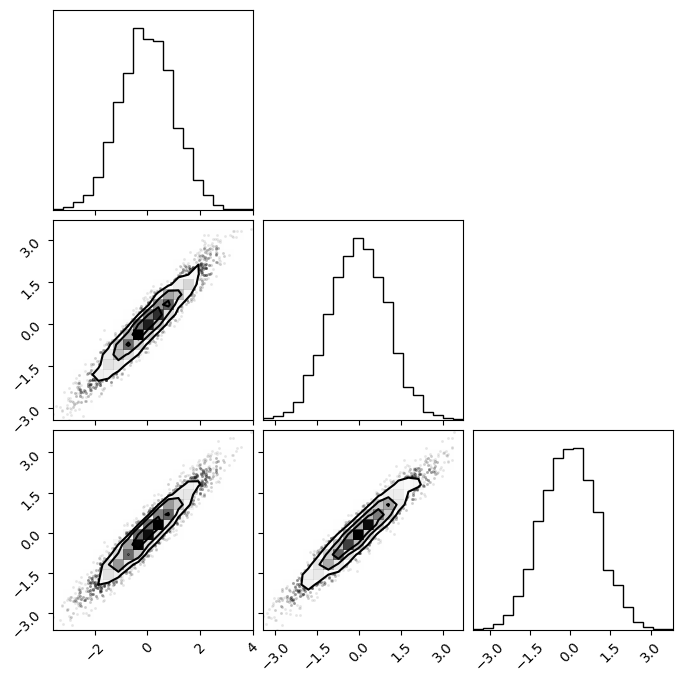

In [25]:
import corner
corner.corner(samples_equal);

The code even helpfully tells you what work you should be citing based on the run configurations that you used.

In [26]:
print(sampler.citations)

Code and Methods:
Speagle (2020): ui.adsabs.harvard.edu/abs/2020MNRAS.493.3132S
Koposov et al. (2024): doi.org/10.5281/zenodo.3348367

Nested Sampling:
Skilling (2004): ui.adsabs.harvard.edu/abs/2004AIPC..735..395S
Skilling (2006): projecteuclid.org/euclid.ba/1340370944



Bounding Method:
Feroz, Hobson & Bridges (2009): ui.adsabs.harvard.edu/abs/2009MNRAS.398.1601F

Sampling Method:




There is a lot to explore in the `dynesty` package. It is not a panacea, and there are some things you may have to tune, e.g. the **number of initialized live points**, and **the evidence tolerance**. Dig into these caveats in your own time for your own research problems.

Additionally, it implements **dynamic nested sampling** that dynamically allocates live points to explore higher posterior regions better at the expense of increasing the relative evidence uncertainty. See https://dynesty.readthedocs.io/en/latest/dynamic.html. 

In [27]:
## "Dynamic" nested sampling.

#dsampler = dynesty.DynamicNestedSampler(loglike, ptform, ndim)
#dsampler.run_nested()
#dresults = dsampler.results

#### Some harder examples... 

Have a look at some of these runs!

https://dynesty.readthedocs.io/en/latest/examples.html

###  UltraNest <a class="anchor" id="twob"></a>

*Refs: MLFriends (Buchner, 2014; 2019) using UltraNest https://johannesbuchner.github.io/UltraNest/*

To see how `UltraNest` works compared to standard MCMC algorithms, go [here](https://johannesbuchner.github.io/UltraNest/method.html#visualisation). 

You should have seen this kind of visualization before for Metropolis-Hastings, but this helps make it clear how the new live points are being chosen from within the prior volume, and how the whole set of points are moving up the likelihood surface.

We'll look at an example from [UltraNest's documentation](https://johannesbuchner.github.io/UltraNest/using-ultranest.html). This involves fitting a **spectral line feature**. There are many other tutorials on the documentation to dig into in your own time.

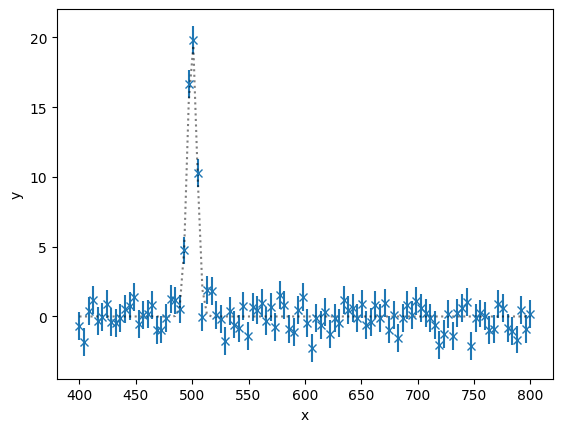

In [28]:
import pylab as plt

# Generate data over a wavelength range with a noisy signal
x = np.linspace(400, 800, 100)
yerr = 1.0
y = np.random.normal(20 * np.exp(-0.5 * ((x-500)/4.2)**2), yerr)

plt.errorbar(x, y, yerr=yerr, ls=' ', marker='x')
plt.plot(x, 20 * np.exp(-0.5 * ((x-500)/4.2)**2), ls=':', alpha=0.5, color='k')
plt.xlabel('x')
plt.ylabel('y');

This problem has 3 parameters: The location, amplitude and width of the gaussian line. We assume that the noise level is known.

In [29]:
param_names = ['location', 'amplitude', 'width']

As in `dynesty`, the parameter space is defined through a transform from unit values ($0,\ldots,1$) to the physical range.

The next function demonstrates:
- a uniform prior for a location parameter
- a log-uniform prior for a scale parameter
- a log-normal prior

In [30]:
def my_prior_transform(cube):
    params = cube.copy()

    # transform location parameter: uniform prior
    lo = 400
    hi = 800
    params[0] = cube[0] * (hi - lo) + lo

    # transform amplitude parameter: log-uniform prior
    lo = 0.1
    hi = 100
    params[1] = 10**(cube[1] * (np.log10(hi) - np.log10(lo)) + np.log10(lo))

    # More complex prior, you can use the ppf functions
    # from scipy.stats, such as scipy.stats.norm(mean, std).ppf

    # transform for width:
    # a log-normal centered at 1 +- 1dex
    params[2] = 10**stats.norm.ppf(cube[2], 0, 1)

    return params

Next, we need to specify the data likelihood given certain parameters:

In [31]:
def my_likelihood(params):
    location, amplitude, width = params
    # compute intensity at every x position according to the model
    y_model = amplitude * np.exp(-0.5 * ((x - location)/width)**2)
    # compare model and data with gaussian likelihood:
    like = -0.5 * (((y_model - y)/yerr)**2).sum()
    return like

Ready to sample!

In [36]:
import ultranest
from scipy import stats

sampler = ultranest.ReactiveNestedSampler(param_names, my_likelihood, 
                                          my_prior_transform)

Take a second to install ipython widgets for some interactive run updates.

In [37]:
# pip install ipywidgets

In [38]:
result = sampler.run()
sampler.print_results()

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-4e+01   [-41.6480..-41.6479]*| it/evals=4480/14445 eff=30.6159% N=220  0   
[ultranest] Likelihood function evaluations: 14449
[ultranest]   logZ = -56.48 +- 0.1815
[ultranest] Effective samples strategy satisfied (ESS = 1051.2, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.10 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.25 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.

logZ = -56.499 +- 0.416
  single instance: logZ = -56.499 +- 0.183
  bootstrapped   : logZ = -56.480 +- 0.416
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    location            : 499.09│ ▁▁▁▁▁▁▁▁▂▂▂▃▃▄▅▄▅▆▇▆▇▅▅▄▃▃▂▂▂▁▁▁▁▁▁▁▁ │500.66    499.88 +- 0.21
    amplitude           : 17.70 │ ▁ ▁▁▁▁▁▁▂▂▃▄▄▆▆▆▇▇▇▆▇▆▄▃▂▂▂▂▁▁▁▁▁▁▁ ▁ │24.71     21.02 +- 0.88
    width               : 3.34  

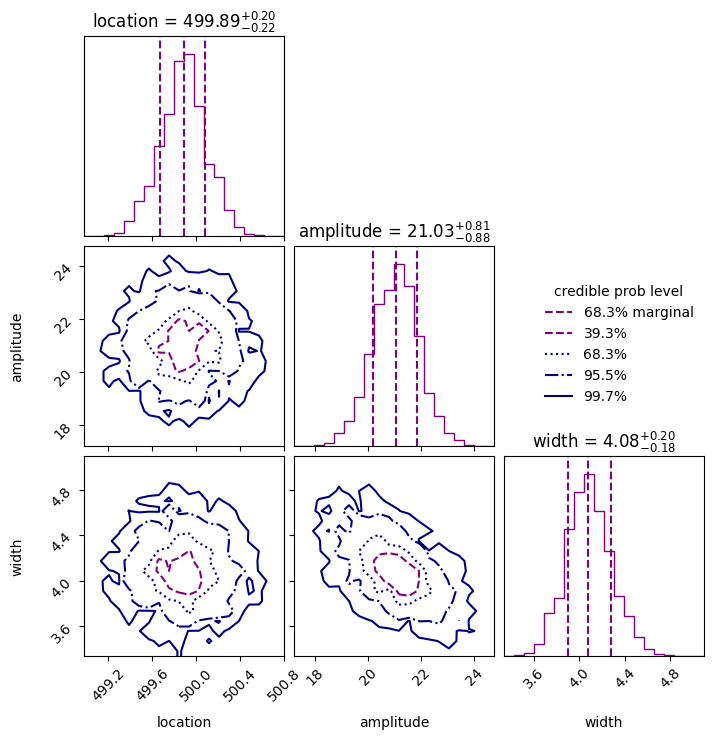

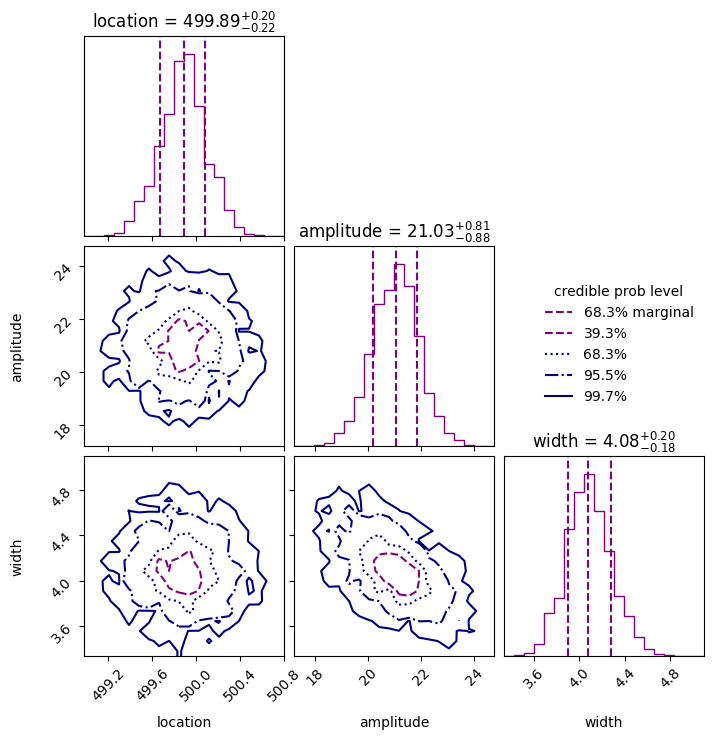

In [39]:
from ultranest.plot import cornerplot
cornerplot(result)

### Back to the nice animation...

Remember last time we looked at [this nice animation of MCMC sampling](https://chi-feng.github.io/mcmc-demo/app.html)?

[This is the equivalent for nested sampling](https://johannesbuchner.github.io/UltraNest/method.html#visualisation), from the UltraNest documentation 


### **Very important (1)** 
Samples that come out of a nested sampling runs are **weighted**. The results of nested sampling and the samples and their weights *together*. Do not use samples by themselves, it doesn't make sense.

### **Very important (2)** 
If an MCMC is taking to long, you can interrupt it and use samples you got so far (assuming you're past the burn in period). This is not possible with nested sampling; samples don't make any sense until the algorithm reached the top of the posterior! You have to let it go till the end.


### Take home message


There is a ton more to explore in nested sampling, evidence evaluation, model comparison, and parameter estimation.

Alas, we must move on. However, these hands-on tutorials using real packages gives you an idea of the rich array of resources you can use for your own research.

Make sure you know what is going on under the hood, but remember often you want to apply things and get the result. 

# Exam exercise

This exercise is in two parts, using datasets we've seen already.

1. Go back to the "Time transients" problem from lecture 5. There we fitted two models, an exponential tail and a gaussian.
 - Fit the same models again using nested sampling
 - Compare the parameter-estimation results against those you got with MCMCs. They should be compatible
 - Evaluate the Bayes factor between the two models and interpret it using the Jeffrey's scale. 
 
2. Go back to the "Higgs boson" problem from lecture 6. There we had two nested models and computed the evidence using Savage Dickey.
 - Fit the same models again using nested sampling.
 - Evaluate the Bayes factor between the two models and interpret it using the Jeffrey's scale. 
 - Is this compatible with your previous estimate? 


In [1]:
# Imports used by the solution below.
import dynesty
import numpy as np
from dynesty import utils as dyfunc
import corner
import pylab as plt

import matplotlib as mpl

mpl.rcParams["text.usetex"] = False

# Solution

Both parts ask the same thing: two models, one dataset, which one do the data prefer? The answer is the Bayes factor

$$ B = \frac{Z_1}{Z_2}, \qquad Z = \int \mathcal{L}(\theta)\,\pi(\theta)\,d\theta $$

$Z$ is the evidence: the likelihood averaged over the prior. Lecture 5 never computed it, because MCMC does not normalize the posterior. Lecture 6 got around it with Savage-Dickey. Here I compute $Z$ directly, with nested sampling.

Two practical points for all the code below.

1. `dynesty` wants a **prior transform**, not a prior density. It draws numbers $u$ uniform in $[0,1]$ and I have to turn them into parameters. A uniform prior $\mathcal{U}[a,b]$ becomes `a + (b-a)*u`. It is the same prior, just written the other way round.
2. The likelihood must keep its **normalization constant** $-\tfrac{1}{2}\sum_i \ln(2\pi\sigma_i^2)$. In MCMC it cancels in the acceptance ratio, so we dropped it. Here it does not cancel: it shifts $\ln Z$. It is the same constant for both models, so it would cancel again in the Bayes factor, but I keep it because I also want to read $\ln Z$ on its own.

In [2]:
SEED = 42


def jeffreys(lnB):
    """Interpretation of a Bayes factor on Jeffreys' scale, working in ln B to avoid overflow."""
    if lnB < 0:
        return "the evidence actually favours the other model"
    if lnB < np.log(3):
        return "barely worth mentioning"
    if lnB < np.log(10):
        return "substantial"
    if lnB < np.log(30):
        return "strong"
    if lnB < np.log(100):
        return "very strong"
    return "decisive"


def summarize(samples, names, title):
    """Median and 90% credible interval, in the same format we used in the MCMC lectures."""
    print(title)
    q = np.percentile(samples, [5, 50, 95], axis=0)
    for i, n in enumerate(names):
        lo, med, hi = q[0, i], q[1, i], q[2, i]
        print(f"  {n:<10} = {med:9.3f}  +{hi - med:.3f} / -{med - lo:.3f}")
    return q[1]


def equal_samples(results):
    """Nested sampling returns WEIGHTED samples; resample them to equal weight before
    doing anything that assumes one sample = one draw from the posterior."""
    weights = np.exp(results.logwt - results.logz[-1])
    return dyfunc.resample_equal(results.samples, weights)

## Part 1: the time transient

Back to `datasets/transient.npy` from lecture 5. The two models are the ones already fitted with `emcee` there, with the same priors, so the posteriors can be compared directly:

| | model | parameters | priors |
|---|---|---|---|
| $M_{\rm exp}$ | $y = b$ for $t<t_0$, $\;y = b + A e^{-\alpha(t-t_0)}$ for $t \geq t_0$ | $b, A, t_0, \ln\alpha$ | $b,A\sim\mathcal{U}[0,50]$, $t_0\sim\mathcal{U}[0,100]$, $\ln\alpha\sim\mathcal{U}[-5,5]$ |
| $M_{\rm gauss}$ | $y = b + A e^{-(t-t_0)^2/2\sigma_W^2}$ | $b, A, t_0, \ln\sigma_W$ | same for $b,A,t_0$; $\ln\sigma_W\sim\mathcal{U}[-2,5]$ |

These two models are **not nested**: there is no choice of parameters that turns an exponential tail into a Gaussian. So Savage-Dickey cannot be used here, and the evidence is the only way to get a Bayes factor. That is exactly why lecture 5 had to leave the question open.

In [3]:
# the data
data = np.load("../datasets/transient.npy")  # (100, 3): time, intensity, uncertainty
t, y, yerr = data[:, 0], data[:, 1], data[:, 2]

# normalization constant of the Gaussian likelihood: -1/2 sum ln(2 pi sigma_i^2).
# It does not depend on the parameters, so we compute it once.
LNORM_T = -0.5 * np.sum(np.log(2 * np.pi * yerr**2))


# the two models
def burst_model(theta, tt):
    """Flat background, then a sharp rise at t0 decaying exponentially."""
    b, A, t0, ln_alpha = theta
    m = np.full_like(tt, b, dtype=float)
    rise = tt >= t0
    m[rise] = b + A * np.exp(-np.exp(ln_alpha) * (tt[rise] - t0))
    return m


def gauss_model(theta, tt):
    """Flat background plus a Gaussian bump."""
    b, A, t0, ln_w = theta
    return b + A * np.exp(-((tt - t0) ** 2) / (2.0 * np.exp(ln_w) ** 2))


# log-likelihoods (normalized)
def loglike_burst(theta):
    return LNORM_T - 0.5 * np.sum(((y - burst_model(theta, t)) / yerr) ** 2)


def loglike_gauss(theta):
    return LNORM_T - 0.5 * np.sum(((y - gauss_model(theta, t)) / yerr) ** 2)


# prior transforms: unit cube -> parameters (same priors as lecture 5)
def ptform_burst(u):
    return np.array(
        [
            50.0 * u[0],  # b        ~ U[0, 50]
            50.0 * u[1],  # A        ~ U[0, 50]
            100.0 * u[2],  # t0       ~ U[0, 100]
            -5.0 + 10.0 * u[3],
        ]
    )  # ln_alpha ~ U[-5, 5]


def ptform_gauss(u):
    return np.array(
        [
            50.0 * u[0],  # b        ~ U[0, 50]
            50.0 * u[1],  # A        ~ U[0, 50]
            100.0 * u[2],  # t0       ~ U[0, 100]
            -2.0 + 7.0 * u[3],
        ]
    )  # ln_sigma_W ~ U[-2, 5]

In [4]:
# Run the two nested sampling analyses.
# nlive=500 is comfortable for a 4-D problem; dlogz=0.05 is the stopping criterion on the
# remaining evidence (stop when what is left to integrate is negligible).
sampler_burst = dynesty.NestedSampler(
    loglike_burst,
    ptform_burst,
    ndim=4,
    nlive=500,
    bound="multi",
    sample="rwalk",
    rstate=np.random.default_rng(SEED),
)
sampler_burst.run_nested(dlogz=0.05, print_progress=True)
res_burst = sampler_burst.results

sampler_gauss = dynesty.NestedSampler(
    loglike_gauss,
    ptform_gauss,
    ndim=4,
    nlive=500,
    bound="multi",
    sample="rwalk",
    rstate=np.random.default_rng(SEED),
)
sampler_gauss.run_nested(dlogz=0.05, print_progress=True)
res_gauss = sampler_gauss.results

logZ_burst, logZ_burst_err = res_burst.logz[-1], res_burst.logzerr[-1]
logZ_gauss, logZ_gauss_err = res_gauss.logz[-1], res_gauss.logzerr[-1]

print()
print(f"ln Z (exponential burst) = {logZ_burst:.3f} +/- {logZ_burst_err:.3f}")
print(f"ln Z (gaussian)          = {logZ_gauss:.3f} +/- {logZ_gauss_err:.3f}")

8871it [00:03, 2254.20it/s, +500 | bound: 18 | nc: 1 | ncall: 189174 | eff(%):  4.967 | loglstar:   -inf < -140.647 <    inf | logz: -155.355 +/-  0.163 | dlogz:  0.000 >  0.050]
9650it [00:03, 2428.72it/s, +500 | bound: 21 | nc: 1 | ncall: 207632 | eff(%):  4.900 | loglstar:   -inf < -144.303 <    inf | logz: -160.571 +/-  0.170 | dlogz:  0.000 >  0.050]


ln Z (exponential burst) = -155.355 +/- 0.183
ln Z (gaussian)          = -160.571 +/- 0.190


equally-weighted samples: 9371 (burst) / 10150 (gaussian)


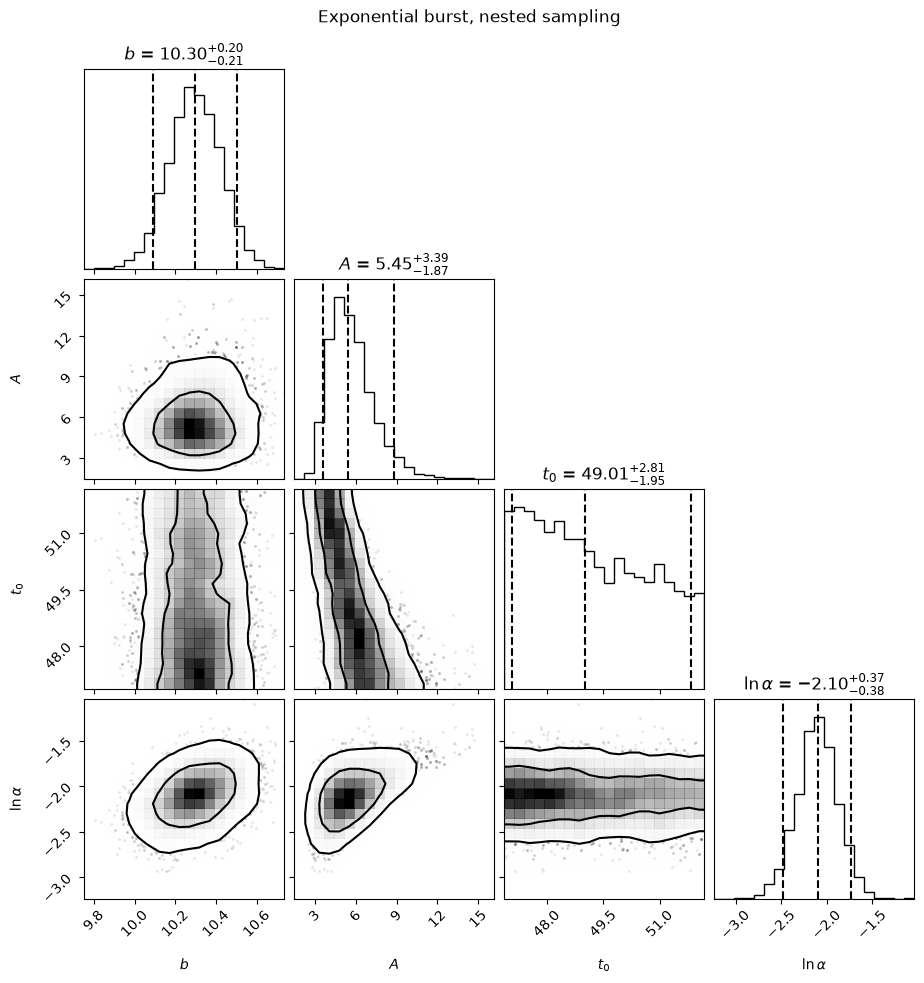

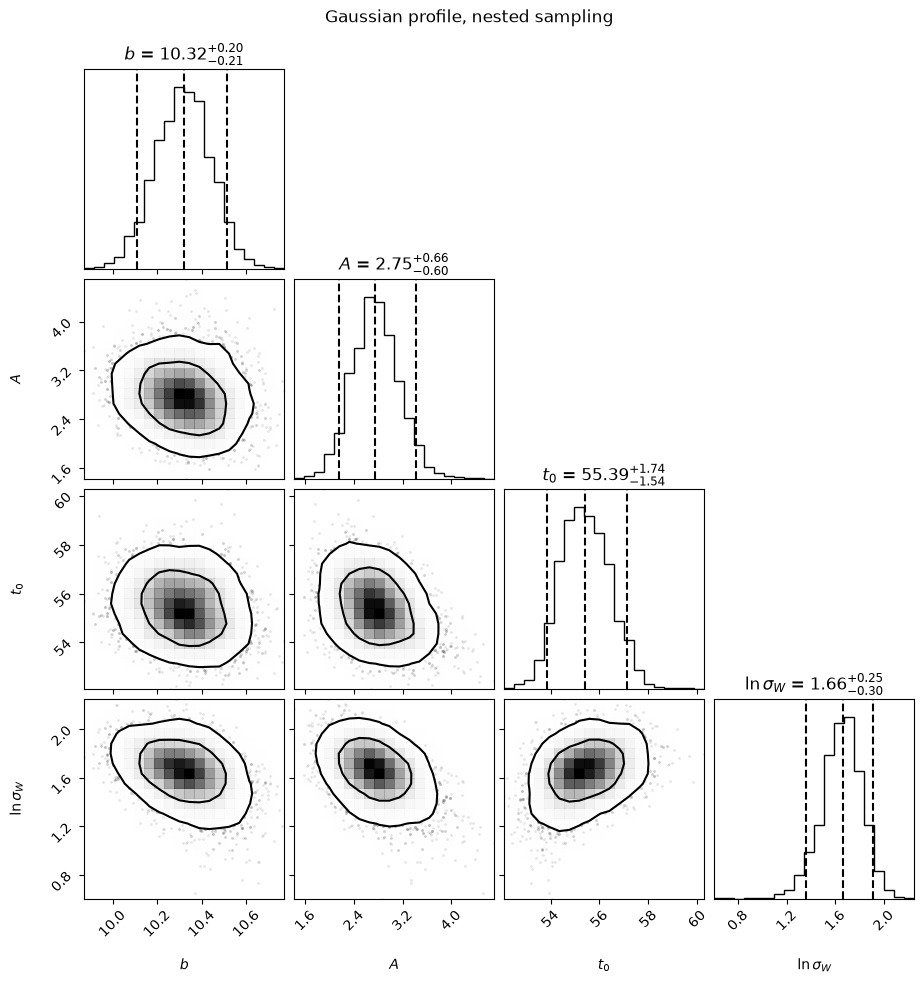

Exponential burst (median, 90% CI):
  b          =    10.297  +0.204 / -0.207
  A          =     5.447  +3.387 / -1.865
  t0         =    49.014  +2.807 / -1.945
  ln_alpha   =    -2.098  +0.365 / -0.379

Gaussian profile (median, 90% CI):
  b          =    10.319  +0.195 / -0.210
  A          =     2.752  +0.660 / -0.597
  t0         =    55.393  +1.736 / -1.541
  ln_sigma_W =     1.662  +0.249 / -0.303


In [5]:
# Posteriors. Remember to resample to equal weights first.
eq_burst = equal_samples(res_burst)
eq_gauss = equal_samples(res_gauss)
print(
    "equally-weighted samples:",
    eq_burst.shape[0],
    "(burst) /",
    eq_gauss.shape[0],
    "(gaussian)",
)

labels_burst = [r"$b$", r"$A$", r"$t_0$", r"$\ln\alpha$"]
labels_gauss = [r"$b$", r"$A$", r"$t_0$", r"$\ln\sigma_W$"]

fig = corner.corner(
    eq_burst,
    labels=labels_burst,
    quantiles=[0.05, 0.5, 0.95],
    levels=(0.68, 0.95),
    show_titles=True,
    title_fmt=".2f",
    smooth=0.8,
)
fig.suptitle("Exponential burst, nested sampling", y=1.02)
plt.show()

fig = corner.corner(
    eq_gauss,
    labels=labels_gauss,
    quantiles=[0.05, 0.5, 0.95],
    levels=(0.68, 0.95),
    show_titles=True,
    title_fmt=".2f",
    smooth=0.8,
)
fig.suptitle("Gaussian profile, nested sampling", y=1.02)
plt.show()

names_burst = ["b", "A", "t0", "ln_alpha"]
names_gauss = ["b", "A", "t0", "ln_sigma_W"]
med_burst = summarize(eq_burst, names_burst, "Exponential burst (median, 90% CI):")
med_gauss = summarize(eq_gauss, names_gauss, "\nGaussian profile (median, 90% CI):")

### Does this agree with the MCMC of lecture 5?

The exercise asks to check that the parameters come out the same. Instead of copying numbers across notebooks, I re-run the two `emcee` fits here. The chains are shorter than in lecture 5, but still much longer than the autocorrelation time. Both samplers target the same posterior, so the medians have to match.

In [6]:
import emcee


def log_prior_burst(theta):
    b, A, t0, ln_alpha = theta
    if 0 <= b <= 50 and 0 <= A <= 50 and 0 <= t0 <= 100 and -5 <= ln_alpha <= 5:
        return 0.0
    return -np.inf


def log_prior_gauss(theta):
    b, A, t0, ln_w = theta
    if 0 <= b <= 50 and 0 <= A <= 50 and 0 <= t0 <= 100 and -2 <= ln_w <= 5:
        return 0.0
    return -np.inf


def make_logpost(log_prior, loglike):
    def log_post(theta):
        lp = log_prior(theta)
        return -np.inf if not np.isfinite(lp) else lp + loglike(theta)

    return log_post


np.random.seed(SEED)
nwalkers, ndim, nsteps = 32, 4, 10000
mcmc_medians = {}
for tag, log_prior, loglike, guess in [
    ("burst", log_prior_burst, loglike_burst, [10.0, 4.0, 52.0, np.log(0.1)]),
    ("gauss", log_prior_gauss, loglike_gauss, [10.0, 4.0, 52.0, np.log(5.0)]),
]:
    p0 = np.array(guess) + 1e-2 * np.random.randn(nwalkers, ndim)
    s = emcee.EnsembleSampler(nwalkers, ndim, make_logpost(log_prior, loglike))
    s.run_mcmc(p0, nsteps, progress=True)
    tau = s.get_autocorr_time(tol=0)
    flat = s.get_chain(discard=int(3 * tau.max()), thin=int(0.5 * tau.min()), flat=True)
    mcmc_medians[tag] = np.median(flat, axis=0)
    print(f"{tag}: tau = {np.round(tau, 1)}, independent samples = {flat.shape[0]}")

100%|██████████| 10000/10000 [00:03<00:00, 2823.58it/s]


burst: tau = [56.6 78.5 75.6 65. ], independent samples = 11136


100%|██████████| 10000/10000 [00:03<00:00, 3178.55it/s]


gauss: tau = [44.6 48.9 45.6 45. ], independent samples = 14304


In [7]:
# side-by-side comparison of the two samplers
print(f"{'parameter':<12}{'MCMC':>12}{'nested':>12}{'difference':>14}")
for tag, names, med_ns in [
    ("burst", names_burst, med_burst),
    ("gauss", names_gauss, med_gauss),
]:
    print(f"-- {tag} model")
    for i, n in enumerate(names):
        a, b_ = mcmc_medians[tag][i], med_ns[i]
        print(f"  {n:<10}{a:12.3f}{b_:12.3f}{b_ - a:14.3f}")

parameter           MCMC      nested    difference
-- burst model
  b               10.298      10.297        -0.001
  A                5.422       5.447         0.025
  t0              49.067      49.014        -0.053
  ln_alpha        -2.096      -2.098        -0.003
-- gauss model
  b               10.316      10.319         0.004
  A                2.748       2.752         0.004
  t0              55.396      55.393        -0.003
  ln_sigma_W       1.663       1.662        -0.001


In [8]:
# The Bayes factor between the two transient models.
lnB = logZ_burst - logZ_gauss
lnB_err = np.hypot(logZ_burst_err, logZ_gauss_err)

print(f"ln B (exponential / gaussian) = {lnB:.2f} +/- {lnB_err:.2f}")
print(f"B                             = {np.exp(lnB):.1f}")
print(f"log10 B                       = {lnB / np.log(10):.2f}")
print(
    f"\nJeffreys' scale: {jeffreys(lnB)} evidence in favour of the exponential burst."
)

ln B (exponential / gaussian) = 5.22 +/- 0.26
B                             = 184.2
log10 B                       = 2.27

Jeffreys' scale: decisive evidence in favour of the exponential burst.


### So, exponential or Gaussian?

**Exponential.**

$$ \ln B = 5.22 \pm 0.26 \quad\Longrightarrow\quad B \approx 184 $$

On Jeffreys' scale anything above $B = 100$ is *decisive*, so this is decisive evidence in favour of the exponential burst.

**Can I trust the number?** $\ln B$ is about 20 times its own error bar, so it is not an artefact of the sampler.

**Where does the factor come from?** Both models have 4 parameters and almost the same prior volume, so this is not a penalty for using more parameters. It comes from the shape of the data: the signal rises abruptly and decays slowly. A Gaussian is symmetric, so it can never reproduce that, however its parameters are set. It only fits acceptably in a narrow corner of its prior, and the evidence is the likelihood *averaged over the whole prior* — so averaging drags $Z_{\rm gauss}$ down. This is the Occam factor.

## Part 2: the Higgs boson

Same data, model and priors as lecture 6, so the two Bayes factors are directly comparable. The model is a falling exponential continuum plus a Gaussian peak,

$$ f(m) = c_0 e^{-c_1 (m-m_0)} + A\,e^{-(m-\mu)^2/2\sigma^2}, $$

with $M_1$ the background only ($c_0, c_1$) and $M_2$ the full model ($c_0, c_1, A, \mu, \ln\sigma$).

These two models **are nested**: setting $A = 0$ in $M_2$ gives $M_1$. That is what made Savage-Dickey possible in lecture 6. Nested sampling does not need them to be nested — it integrates each model separately and divides — and the two answers should agree. Checking that is the point of this part.

One detail for the comparison: I keep the prior $A \sim \mathcal{U}[-2,2]$ from lecture 6, negative amplitudes included, because Savage-Dickey needs $A=0$ to lie inside the prior. Restricting to $A>0$ would halve the prior volume and shift $\ln B$ by $\ln 2$, and the two numbers would no longer be comparable.

In [9]:
# the data (already loaded above in this notebook's lecture part, reloaded here to be safe)
mass, eventpermassbin, eventerr = np.loadtxt("../datasets/boson.txt", unpack=True)
m0 = mass.min()  # fixed reference mass, not a free parameter
LNORM_H = -0.5 * np.sum(np.log(2 * np.pi * eventerr**2))


def background(theta, m):
    c0, c1 = theta[0], theta[1]
    return c0 * np.exp(-c1 * (m - m0))


def signal_plus_background(theta, m):
    c0, c1, A, mu, ln_sigma = theta
    return background(theta, m) + A * np.exp(-0.5 * ((m - mu) / np.exp(ln_sigma)) ** 2)


def loglike_M2(theta):  # Higgs
    return LNORM_H - 0.5 * np.sum(
        ((eventpermassbin - signal_plus_background(theta, mass)) / eventerr) ** 2
    )


def loglike_M1(theta):  # background only
    return LNORM_H - 0.5 * np.sum(
        ((eventpermassbin - background(theta, mass)) / eventerr) ** 2
    )


# prior transforms, identical to the priors of lecture 6
LN_S_LO, LN_S_HI = np.log(0.5), np.log(8.0)
A_LO, A_HI = -2.0, 2.0


def ptform_M2(u):
    return np.array(
        [
            10.0 * u[0],  # c0       ~ U[0, 10]
            1.0 * u[1],  # c1       ~ U[0, 1]
            A_LO + (A_HI - A_LO) * u[2],  # A        ~ U[-2, 2]
            118.0 + 14.0 * u[3],  # mu       ~ U[118, 132]
            LN_S_LO + (LN_S_HI - LN_S_LO) * u[4],
        ]
    )  # ln_sigma ~ U[ln 0.5, ln 8]


def ptform_M1(u):
    return np.array([10.0 * u[0], 1.0 * u[1]])

In [10]:
# nlive=1000 here: the signal parameters (A, mu, sigma) carve out a thin, well-localized
# region of the prior, and a generous number of live points keeps the evidence stable.
sampler_M2 = dynesty.NestedSampler(
    loglike_M2,
    ptform_M2,
    ndim=5,
    nlive=1000,
    bound="multi",
    sample="rwalk",
    rstate=np.random.default_rng(SEED),
)
sampler_M2.run_nested(dlogz=0.05, print_progress=True)
res_M2 = sampler_M2.results

sampler_M1 = dynesty.NestedSampler(
    loglike_M1,
    ptform_M1,
    ndim=2,
    nlive=1000,
    bound="multi",
    sample="rwalk",
    rstate=np.random.default_rng(SEED),
)
sampler_M1.run_nested(dlogz=0.05, print_progress=True)
res_M1 = sampler_M1.results

logZ_M2, logZ_M2_err = res_M2.logz[-1], res_M2.logzerr[-1]
logZ_M1, logZ_M1_err = res_M1.logz[-1], res_M1.logzerr[-1]

print()
print(f"ln Z (M2, background + Higgs) = {logZ_M2:.3f} +/- {logZ_M2_err:.3f}")
print(f"ln Z (M1, background only)    = {logZ_M1:.3f} +/- {logZ_M1_err:.3f}")

22341it [00:09, 2408.20it/s, +1000 | bound: 20 | nc: 1 | ncall: 506700 | eff(%):  4.616 | loglstar:   -inf < 61.561 <    inf | logz: 42.237 +/-  0.131 | dlogz:  0.000 >  0.050]
14812it [00:05, 2939.18it/s, +1000 | bound: 12 | nc: 1 | ncall: 283881 | eff(%):  5.590 | loglstar:   -inf < 40.897 <    inf | logz: 29.113 +/-  0.104 | dlogz:  0.000 >  0.050]


ln Z (M2, background + Higgs) = 42.237 +/- 0.147
ln Z (M1, background only)    = 29.113 +/- 0.119


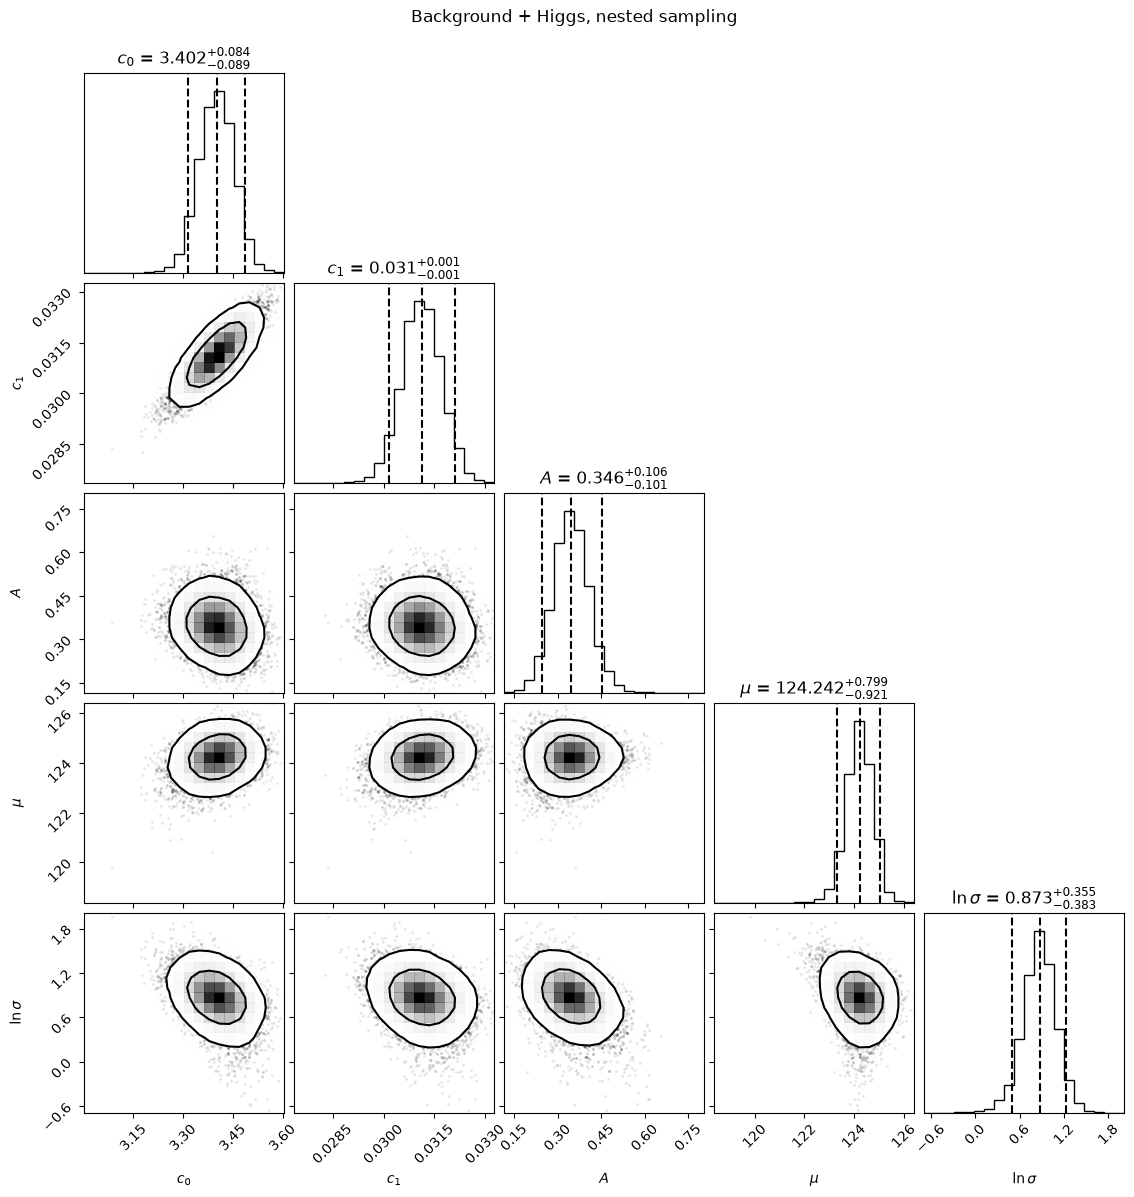

Background + Higgs (median, 90% CI):
  c0         =     3.402  +0.084 / -0.089
  c1         =     0.031  +0.001 / -0.001
  A          =     0.346  +0.106 / -0.101
  mu         =   124.242  +0.799 / -0.921
  ln_sigma   =     0.873  +0.355 / -0.383

  Higgs mass  mu    = 124.24 GeV
  peak width  sigma = 2.39 GeV


In [11]:
eq_M2 = equal_samples(res_M2)
eq_M1 = equal_samples(res_M1)

labels_M2 = [r"$c_0$", r"$c_1$", r"$A$", r"$\mu$", r"$\ln\sigma$"]
fig = corner.corner(
    eq_M2,
    labels=labels_M2,
    quantiles=[0.05, 0.5, 0.95],
    levels=(0.68, 0.95),
    show_titles=True,
    title_fmt=".3f",
    smooth=0.8,
)
fig.suptitle("Background + Higgs, nested sampling", y=1.02)
plt.show()

med_M2 = summarize(
    eq_M2, ["c0", "c1", "A", "mu", "ln_sigma"], "Background + Higgs (median, 90% CI):"
)
print(f"\n  Higgs mass  mu    = {med_M2[3]:.2f} GeV")
print(f"  peak width  sigma = {np.exp(med_M2[4]):.2f} GeV")

In [12]:
# The Bayes factor from the evidences.
lnB10 = logZ_M2 - logZ_M1
lnB10_err = np.hypot(logZ_M2_err, logZ_M1_err)

print(f"ln B (Higgs / no Higgs) = {lnB10:.2f} +/- {lnB10_err:.2f}")
print(f"log10 B                 = {lnB10 / np.log(10):.2f}")
print(f"B                       = {np.exp(lnB10):.3e}")
print(f"\nJeffreys' scale: {jeffreys(lnB10)} evidence for the Higgs signal.")

ln B (Higgs / no Higgs) = 13.12 +/- 0.19
log10 B                 = 5.70
B                       = 5.010e+05

Jeffreys' scale: decisive evidence for the Higgs signal.


### Is this compatible with lecture 6?

**Yes.**

| method | $\log_{10} B$ |
|---|---|
| lecture 6, Savage-Dickey | $\approx 5.5$ |
| lecture 7, nested sampling | $5.70 \pm 0.08$ |

Jeffreys calls $B > 100$, i.e. $\log_{10}B > 2$, decisive. Both numbers are far above that, so both say the same thing: the Higgs peak is really there.

**Why are they not identical?** Not because the two methods disagree. For nested models Savage-Dickey is an exact identity, not an approximation:

$$ B = \frac{\pi(A=0)}{p(A=0 \mid d)} $$

The difference comes from how lecture 6 had to evaluate the denominator. $A = 0$ sits about $6\sigma$ away from the peak of the posterior of $A$, and no sampler ever puts points that far into the tail. So lecture 6 fitted a Gaussian to the posterior of $A$ and read the density off that fit. *That* is the approximation. At $6\sigma$ a 10% error on $\sigma_A$ moves $\log_{10}B$ by about a full unit, so a difference of a couple of tenths is exactly what you would expect.

Nested sampling never has to extrapolate into a tail: it integrates over the whole prior directly. So $5.70$ is the more reliable of the two numbers.

**The trade-off.** Savage-Dickey is free once you already have an MCMC, but it only works for nested models and it is least accurate precisely where the evidence is strongest, far out in the tail. Nested sampling costs one full run per model, but it gives $Z$ for any pair of models, nested or not, which is the only reason Part 1 was answerable at all.